# Marketing Mix Modelling (MMM) - Budget Optimisation

## Step 1: Data Loading and Initial Setup

### Objective
The objective of this project is to build a Marketing Mix Modelling (MMM) framework to understand the impact of different marketing channels on revenue performance.

This project will:
- Analyse marketing channel effectiveness
- Estimate channel contribution to revenue
- Evaluate marketing ROI
- Support budget allocation decisions

### Dataset
The dataset contains weekly marketing performance data including:
- Paid Search spend
- Paid Social spend
- Display advertising spend
- Email marketing activity
- Promotions
- Seasonality factors
- Revenue (target variable)

**Note:** This dataset is synthetic and created for portfolio/learning purposes.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Marketing Data

In a real-world environment, marketing data may come from multiple sources such as:
- Advertising platforms (Google Ads, Meta Ads)
- CRM platforms (Emarsys, Adobe Campaign)
- Web analytics tools (GA4)
- Sales databases or data warehouses

For this project, the data is provided as an Excel file.

In [5]:
# Define file location

file_path = r"C:\& Satheesh\& Git\Marketing-Mix-Modelling-Budget-Optimisation\data\marketing_data.xlsx"


# Load marketing dataset

df = pd.read_excel(
    file_path,
    sheet_name="marketing_data"
)


# Display first five records

df.head()

,week,paid_search_spend,paid_social_spend,display_spend,email_sends,promotion,seasonality_index,revenue
0,2024-01-07,6824,3204,3253,82098,0,1.000,94984.61
1,2024-01-14,13935,3712,5837,105302,1,1.014,138032.02
2,2024-01-21,6535,4791,2905,116237,0,1.029,89555.53
3,2024-01-28,13928,6436,2805,108878,0,1.043,130398.64
4,2024-02-04,5106,9216,2307,141506,0,1.056,108805.05


## Initial Dataset Review

The first step after loading data is to understand:
- Number of observations
- Available variables
- Data structure
- Potential data quality issues

This helps ensure the dataset is suitable for analysis before modelling.

In [8]:
# Check dataset dimensions

df.shape

(104, 8)

In [10]:
# Review dataset columns

df.columns

Index(['week', 'paid_search_spend', 'paid_social_spend', 'display_spend',
       'email_sends', 'promotion', 'seasonality_index', 'revenue'],
      dtype='object')

# Step 2: Data Quality Assessment

## Objective

Before developing a Marketing Mix Model, we need to assess the quality and structure of the dataset.

The checks performed in this stage include:

- Dataset structure and data types
- Missing value analysis
- Duplicate record checks
- Statistical summary
- Date range validation
- Identification of potential data issues

Good data quality is essential because incorrect or incomplete data can impact model accuracy and business recommendations.

## Dataset Structure

The first check is to understand:
- Number of rows and columns
- Column names
- Data types
- Memory usage

This helps identify whether variables are correctly loaded.

In [14]:
# Review dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   week               104 non-null    datetime64[ns]
 1   paid_search_spend  104 non-null    int64         
 2   paid_social_spend  104 non-null    int64         
 3   display_spend      104 non-null    int64         
 4   email_sends        104 non-null    int64         
 5   promotion          104 non-null    int64         
 6   seasonality_index  104 non-null    float64       
 7   revenue            104 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(5)
memory usage: 6.6 KB


## Missing Value Analysis

Missing values can affect statistical modelling.

We check each column to identify whether any data needs cleaning or treatment.

In [19]:
# Check missing values

df.isnull().sum()

week                 0
paid_search_spend    0
paid_social_spend    0
display_spend        0
email_sends          0
promotion            0
seasonality_index    0
revenue              0
dtype: int64

## Duplicate Record Check

Each row represents one week of marketing activity.

Duplicate weeks could distort model results, so we check for duplicate records.

In [22]:
# Count duplicate rows

df.duplicated().sum()

0

## Statistical Summary

We review descriptive statistics to understand:

- Minimum and maximum values
- Average marketing spend
- Revenue distribution
- Potential abnormal values

In [27]:
# Generate statistical summary

df.describe()

,week,paid_search_spend,paid_social_spend,display_spend,email_sends,promotion,seasonality_index,revenue
count,104,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,2025-01-01 12:00:00,9986.221154,6512.615385,3650.932692,97029.750000,0.240385,1.031154,122314.754712
min,2024-01-07 00:00:00,5027.000000,3004.000000,1003.000000,51220.000000,0.000000,0.880000,81056.500000
25%,2024-07-05 06:00:00,6830.000000,4781.000000,2459.750000,78452.250000,0.000000,0.953750,109092.885000
50%,2025-01-01 12:00:00,10393.000000,6581.500000,3561.000000,93386.500000,0.000000,1.062000,122585.315000
75%,2025-06-30 18:00:00,12497.500000,8425.000000,4982.250000,120124.500000,0.000000,1.106000,137888.860000
max,2025-12-28 00:00:00,14697.000000,9904.000000,5906.000000,148536.000000,1.000000,1.166000,161747.540000
std,NaN,2955.505765,2007.381187,1426.165817,27525.182409,0.429386,0.088750,18009.549088


## Date Range Validation

MMM models usually use time-series data.

We confirm:
- Start date
- End date
- Number of weekly observations
- Whether weeks are continuous

In [30]:
# Check date range

print("Start date:", df["week"].min())
print("End date:", df["week"].max())
print("Number of weeks:", df["week"].nunique())

Start date: 2024-01-07 00:00:00
End date: 2025-12-28 00:00:00
Number of weeks: 104


## Data Quality Assessment Summary

The dataset contains 104 weekly observations with 8 variables.

- No missing values detected
- No duplicate records identified
- All marketing spend variables are numeric
- Revenue variable is available as the modelling target
- Weekly time series is complete

The dataset is suitable for exploratory analysis and modelling.

# Step 3: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) helps us understand patterns, relationships and trends within the marketing dataset before developing the Marketing Mix Model.

The analysis will cover:

- Revenue trends over time
- Marketing channel spend trends
- Seasonal patterns
- Correlation between marketing activity and revenue
- Initial business observations

EDA helps identify important variables and potential data issues before modelling.

## Revenue Trend Over Time

Revenue is the target variable for the Marketing Mix Model.

Understanding revenue trends helps identify:
- Growth patterns
- Seasonal changes
- Unusual fluctuations

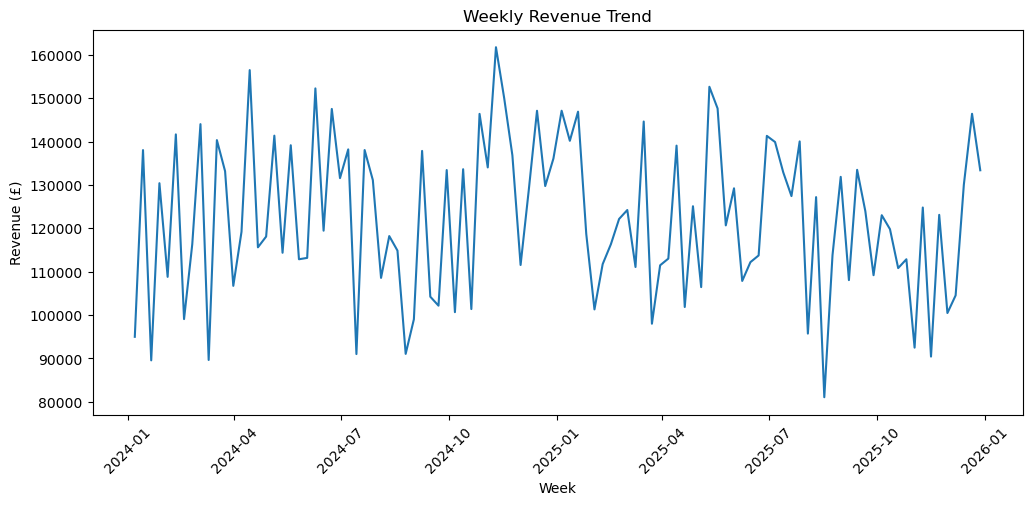

In [35]:
plt.figure(figsize=(12,5))

plt.plot(
    df["week"],
    df["revenue"]
)

plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.show()

## Marketing Channel Spend Trends

Understanding investment patterns across channels helps identify:

- Channel budget allocation
- Changes in marketing activity
- Potential relationships with revenue

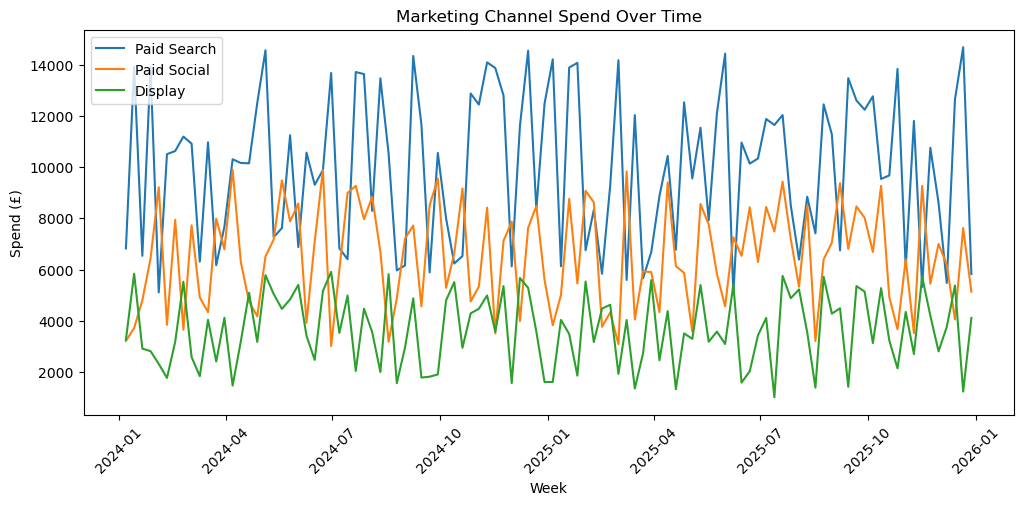

In [38]:
plt.figure(figsize=(12,5))

plt.plot(
    df["week"],
    df["paid_search_spend"],
    label="Paid Search"
)

plt.plot(
    df["week"],
    df["paid_social_spend"],
    label="Paid Social"
)

plt.plot(
    df["week"],
    df["display_spend"],
    label="Display"
)


plt.title("Marketing Channel Spend Over Time")
plt.xlabel("Week")
plt.ylabel("Spend (£)")

plt.legend()

plt.xticks(rotation=45)

plt.show()

## Revenue Distribution

Understanding the distribution of revenue helps identify:

- Typical revenue levels
- Variability
- Potential outliers

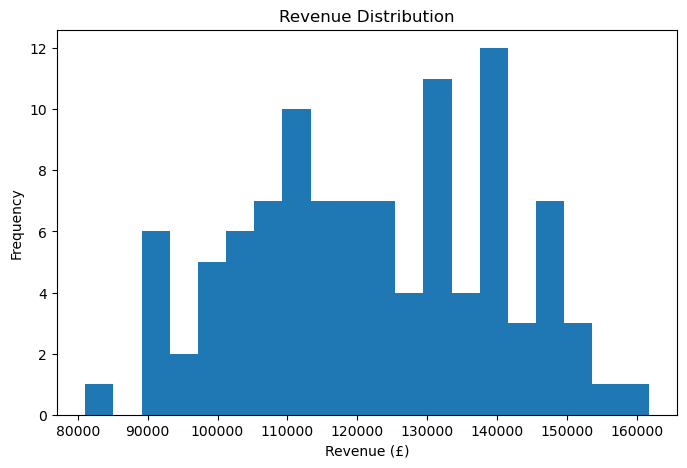

In [41]:
plt.figure(figsize=(8,5))

plt.hist(
    df["revenue"],
    bins=20
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue (£)")
plt.ylabel("Frequency")

plt.show()

## Correlation Analysis

Correlation analysis helps identify relationships between marketing variables and revenue.

Note:
Correlation does not prove causation. It only shows whether variables move together.

In [44]:
correlation = df.corr(numeric_only=True)

correlation["revenue"].sort_values(
    ascending=False
)

revenue              1.000000
paid_search_spend    0.580481
promotion            0.528125
seasonality_index    0.177062
display_spend        0.092225
paid_social_spend    0.035412
email_sends         -0.021991
Name: revenue, dtype: float64

## EDA Summary

Initial analysis identified:

- Revenue trends over the 104-week period
- Marketing investment patterns across channels
- Seasonal behaviour in performance
- Relationships between marketing activity and revenue

These insights will guide feature engineering and model development.

# Step 4: Feature Engineering for MMM

## Objective

Feature engineering transforms raw marketing data into variables that better represent real-world marketing effects.

Marketing impact is not always immediate. Advertising can influence customers over time and the impact may reduce as spend increases.

The following transformations will be applied:

- Time-based features
- Adstock transformation
- Saturation transformation

## Creating Time-Based Features

Marketing performance is influenced by seasonal patterns such as:

- Monthly demand changes
- Holiday periods
- Quarterly business cycles

We create time features to capture these patterns.

In [49]:
# Ensure week column is datetime

df["week"] = pd.to_datetime(df["week"])


# Create time features

df["year"] = df["week"].dt.year

df["month"] = df["week"].dt.month

df["quarter"] = df["week"].dt.quarter


# Display result

df.head()

,week,paid_search_spend,paid_social_spend,display_spend,email_sends,promotion,seasonality_index,revenue,year,month,quarter
0,2024-01-07,6824,3204,3253,82098,0,1.000,94984.61,2024,1,1
1,2024-01-14,13935,3712,5837,105302,1,1.014,138032.02,2024,1,1
2,2024-01-21,6535,4791,2905,116237,0,1.029,89555.53,2024,1,1
3,2024-01-28,13928,6436,2805,108878,0,1.043,130398.64,2024,1,1
4,2024-02-04,5106,9216,2307,141506,0,1.056,108805.05,2024,2,1


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   week               104 non-null    datetime64[ns]
 1   paid_search_spend  104 non-null    int64         
 2   paid_social_spend  104 non-null    int64         
 3   display_spend      104 non-null    int64         
 4   email_sends        104 non-null    int64         
 5   promotion          104 non-null    int64         
 6   seasonality_index  104 non-null    float64       
 7   revenue            104 non-null    float64       
 8   year               104 non-null    int32         
 9   month              104 non-null    int32         
 10  quarter            104 non-null    int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(5)
memory usage: 7.8 KB


In [53]:
df.head()

,week,paid_search_spend,paid_social_spend,display_spend,email_sends,promotion,seasonality_index,revenue,year,month,quarter
0,2024-01-07,6824,3204,3253,82098,0,1.000,94984.61,2024,1,1
1,2024-01-14,13935,3712,5837,105302,1,1.014,138032.02,2024,1,1
2,2024-01-21,6535,4791,2905,116237,0,1.029,89555.53,2024,1,1
3,2024-01-28,13928,6436,2805,108878,0,1.043,130398.64,2024,1,1
4,2024-02-04,5106,9216,2307,141506,0,1.056,108805.05,2024,2,1


## Adstock Transformation

Advertising activity can have a delayed impact on customer behaviour.

The adstock transformation applies a decay factor to previous marketing activity to represent the carryover effect of advertising over time.

Formula:

Adstock(t) = Spend(t) + decay × Adstock(t-1)

Where:

- Spend(t) = current week's marketing spend
- decay = percentage of previous impact retained
- Adstock(t-1) = previous week's advertising effect

A higher decay value means advertising impact lasts longer.

In [56]:
def apply_adstock(series, decay_rate=0.5):
    """
    Apply adstock transformation to marketing activity.
    
    Parameters:
    series: marketing spend time series
    decay_rate: proportion of previous effect carried forward
    
    Returns:
    transformed marketing impact
    """
    
    adstocked = []
    
    previous = 0
    
    for value in series:
        current = value + (previous * decay_rate)
        adstocked.append(current)
        previous = current
        
    return pd.Series(adstocked)

In [58]:
df["paid_search_adstock"] = apply_adstock(
    df["paid_search_spend"],
    decay_rate=0.5
)


df["paid_social_adstock"] = apply_adstock(
    df["paid_social_spend"],
    decay_rate=0.5
)


df["display_adstock"] = apply_adstock(
    df["display_spend"],
    decay_rate=0.5
)

In [60]:
df[
    [
        "paid_search_spend",
        "paid_search_adstock"
    ]
].head(10)

,paid_search_spend,paid_search_adstock
0,6824,6824.000000
1,13935,17347.000000
2,6535,15208.500000
3,13928,21532.250000
4,5106,15872.125000
5,10514,18450.062500
6,10635,19860.031250
7,11201,21131.015625
8,10925,21490.507812
9,6307,17052.253906


## Adstock Summary

Adstock transformations were applied to marketing channels to capture delayed advertising impact.

This allows the MMM model to consider that marketing activity can influence customer behaviour beyond the week when spend occurred.

In [63]:
df[["paid_search_spend","paid_search_adstock"]].head(10)

,paid_search_spend,paid_search_adstock
0,6824,6824.000000
1,13935,17347.000000
2,6535,15208.500000
3,13928,21532.250000
4,5106,15872.125000
5,10514,18450.062500
6,10635,19860.031250
7,11201,21131.015625
8,10925,21490.507812
9,6307,17052.253906


# Saturation Transformation

## Objective

Marketing channels typically experience diminishing returns.

The saturation transformation models the relationship between marketing investment and incremental impact.

This prevents the MMM model from assuming that doubling marketing spend will always double revenue.

A saturation curve helps estimate:
- Optimal investment levels
- Channel efficiency
- Budget allocation opportunities

In [67]:
def apply_saturation(series, alpha=1.5, half_saturation=None):
    """
    Apply saturation transformation to marketing activity.
    
    Parameters:
    series: marketing activity after adstock
    alpha: controls curve shape
    half_saturation: point where response reaches 50%
    
    Returns:
    saturated marketing effect
    """
    
    if half_saturation is None:
        half_saturation = series.mean()
    
    saturated = (
        series ** alpha
    ) / (
        series ** alpha + half_saturation ** alpha
    )
    
    return saturated

In [69]:
df["paid_search_saturation"] = apply_saturation(
    df["paid_search_adstock"]
)


df["paid_social_saturation"] = apply_saturation(
    df["paid_social_adstock"]
)


df["display_saturation"] = apply_saturation(
    df["display_adstock"]
)

In [71]:
df[
    [
        "paid_search_adstock",
        "paid_search_saturation"
    ]
].head(10)

,paid_search_adstock,paid_search_saturation
0,6824.000000,0.168303
1,17347.000000,0.450601
2,15208.500000,0.402372
3,21532.250000,0.531447
4,15872.125000,0.417870
5,18450.062500,0.473582
6,19860.031250,0.501173
7,21131.015625,0.524416
8,21490.507812,0.530722
9,17052.253906,0.444246


## Saturation Summary

A saturation transformation was applied to marketing channel activity to capture diminishing returns.

Combining adstock and saturation allows the MMM model to represent:
- Delayed advertising impact
- Reduced incremental returns at higher spend levels
- More realistic channel contribution estimates

In [76]:
df[[
    "paid_search_adstock",
    "paid_search_saturation"
]].head(10)

,paid_search_adstock,paid_search_saturation
0,6824.000000,0.168303
1,17347.000000,0.450601
2,15208.500000,0.402372
3,21532.250000,0.531447
4,15872.125000,0.417870
5,18450.062500,0.473582
6,19860.031250,0.501173
7,21131.015625,0.524416
8,21490.507812,0.530722
9,17052.253906,0.444246


# Step 5: Marketing Mix Model - Regression

## Objective

A regression-based Marketing Mix Model is developed to estimate the relationship between marketing activity and revenue.

The model uses:
- Saturated marketing channel variables
- Promotional activity
- Seasonality indicators
- Time-based features

The target variable is weekly revenue.

## Define Model Variables

The model requires:

- Independent variables (X): marketing and business drivers
- Dependent variable (y): revenue outcome


In [80]:
# Define model features

features = [
    "paid_search_saturation",
    "paid_social_saturation",
    "display_saturation",
    "email_sends",
    "promotion",
    "seasonality_index",
    "month",
    "quarter"
]


X = df[features]

y = df["revenue"]


# Display feature dataset

X.head()

,paid_search_saturation,paid_social_saturation,display_saturation,email_sends,promotion,seasonality_index,month,quarter
0,0.168303,0.109986,0.231655,82098,0,1.000,1,1
1,0.450601,0.208834,0.511668,105302,1,1.014,1,1
2,0.402372,0.304583,0.467689,116237,0,1.029,1,1
3,0.531447,0.411008,0.437778,108878,0,1.043,1,1
4,0.417870,0.538047,0.389960,141506,0,1.056,2,1


## Train-Test Split

To evaluate model performance, the dataset is divided into:

Training data:
- Used to learn relationships

Testing data:
- Used to evaluate performance on unseen data

Because this is time-series marketing data, we maintain the chronological order.

In [83]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)


print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 83
Testing rows: 21


## Train Regression Model

A linear regression model is used as the baseline MMM approach.

The model estimates the contribution of each marketing variable while controlling for other factors.

In [86]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()


model.fit(
    X_train,
    y_train
)

LinearRegression()

In [88]:
# Predict revenue on test data

y_pred = model.predict(X_test)


y_pred[:5]

array([107592.42178493, 103437.52914657, 114711.83545912, 140327.07577192,
       129262.46529315])

In [90]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})


coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
0,paid_search_saturation,128311.537401
5,seasonality_index,40527.819340
4,promotion,23085.661095
7,quarter,4332.123551
1,paid_social_saturation,4232.856926
2,display_saturation,110.097753
3,email_sends,0.045138
6,month,-1048.952309


# Step 6: Model Evaluation

## Objective

Model evaluation measures how well the MMM model explains and predicts revenue performance.

The evaluation metrics used are:

- R² score
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

These metrics help assess model reliability before using it for marketing investment decisions.

In [95]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np


# Calculate evaluation metrics

r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


print("R²:", round(r2, 3))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

R²: 0.287
MAE: 10984.25
RMSE: 13427.18


# Actual vs Predicted Revenue

Comparing actual revenue against model predictions helps evaluate how well the MMM captures historical performance patterns.

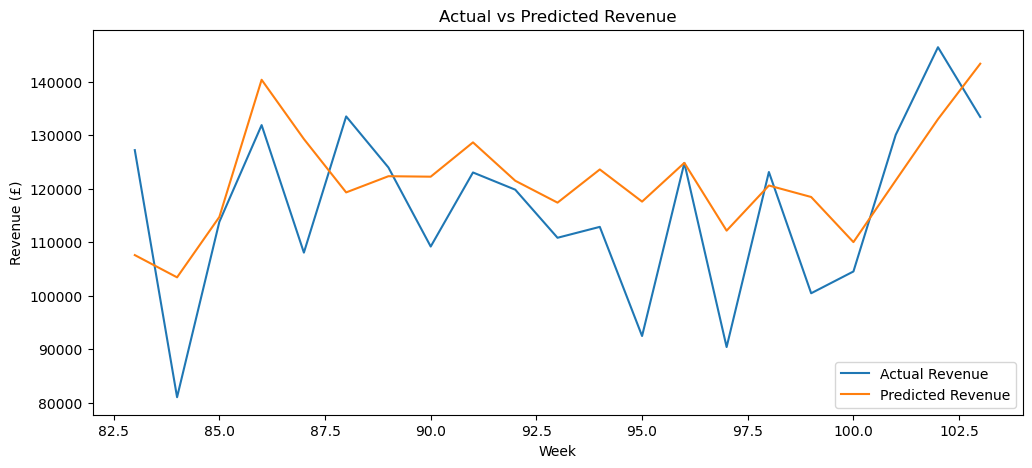

In [98]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Revenue"
)

plt.plot(
    y_test.index,
    y_pred,
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue (£)")

plt.legend()

plt.show()

# Step 7: Marketing Channel Contribution Analysis

## Objective

The purpose of MMM is not only to predict revenue but also to estimate the contribution of each marketing channel.

This analysis helps answer:

- Which channels drive the most revenue impact?
- How should marketing investment be evaluated?
- Which channels may require budget optimisation?


In [101]:
# Create coefficient table

channel_contribution = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})


channel_contribution

,Feature,Coefficient
0,paid_search_saturation,128311.537401
1,paid_social_saturation,4232.856926
2,display_saturation,110.097753
3,email_sends,0.045138
4,promotion,23085.661095
5,seasonality_index,40527.819340
6,month,-1048.952309
7,quarter,4332.123551


## Calculate Estimated Channel Contribution

The regression coefficients represent the relationship between each variable and revenue.

To estimate channel contribution, we multiply each channel's modelled activity by its coefficient.

This converts model output into a business interpretation.

In [104]:
# Calculate contribution from each model variable

contribution_df = X_test.copy()

for feature, coefficient in zip(features, model.coef_):
    contribution_df[feature + "_contribution"] = (
        contribution_df[feature] * coefficient
    )


contribution_df.head()

,paid_search_saturation,paid_social_saturation,display_saturation,email_sends,promotion,seasonality_index,month,quarter,paid_search_saturation_contribution,paid_social_saturation_contribution,display_saturation_contribution,email_sends_contribution,promotion_contribution,seasonality_index_contribution,month_contribution,quarter_contribution
83,0.445087,0.558274,0.554633,79444,0,0.932,8,3,57109.839517,2363.094436,61.063891,3585.911716,0.000000,37771.927624,-8391.618474,12996.370654
84,0.419874,0.431581,0.402861,82092,0,0.920,8,3,53874.741611,1826.818989,44.354065,3705.436088,0.000000,37285.593792,-8391.618474,12996.370654
85,0.511979,0.465236,0.560039,75485,0,0.910,8,3,65692.788248,1969.276071,61.658994,3407.211946,0.000000,36880.315599,-8391.618474,12996.370654
86,0.531085,0.500561,0.561090,81979,1,0.901,8,3,68144.349943,2118.804675,61.774695,3700.335539,23085.661095,36515.565225,-8391.618474,12996.370654
87,0.453900,0.576051,0.570528,78683,1,0.894,9,3,58240.585104,2438.340435,62.813878,3551.562000,23085.661095,36231.870490,-9440.570784,12996.370654


In [106]:
# Sum total contribution by feature

channel_summary = pd.DataFrame({
    "Channel": [
        "Paid Search",
        "Paid Social",
        "Display"
    ],
    
    "Contribution": [
        contribution_df["paid_search_saturation_contribution"].sum(),
        contribution_df["paid_social_saturation_contribution"].sum(),
        contribution_df["display_saturation_contribution"].sum()
    ]
})


channel_summary

,Channel,Contribution
0,Paid Search,1.351991e+06
1,Paid Social,4.456681e+04
2,Display,1.195864e+03


In [108]:
contribution_df.head()

,paid_search_saturation,paid_social_saturation,display_saturation,email_sends,promotion,seasonality_index,month,quarter,paid_search_saturation_contribution,paid_social_saturation_contribution,display_saturation_contribution,email_sends_contribution,promotion_contribution,seasonality_index_contribution,month_contribution,quarter_contribution
83,0.445087,0.558274,0.554633,79444,0,0.932,8,3,57109.839517,2363.094436,61.063891,3585.911716,0.000000,37771.927624,-8391.618474,12996.370654
84,0.419874,0.431581,0.402861,82092,0,0.920,8,3,53874.741611,1826.818989,44.354065,3705.436088,0.000000,37285.593792,-8391.618474,12996.370654
85,0.511979,0.465236,0.560039,75485,0,0.910,8,3,65692.788248,1969.276071,61.658994,3407.211946,0.000000,36880.315599,-8391.618474,12996.370654
86,0.531085,0.500561,0.561090,81979,1,0.901,8,3,68144.349943,2118.804675,61.774695,3700.335539,23085.661095,36515.565225,-8391.618474,12996.370654
87,0.453900,0.576051,0.570528,78683,1,0.894,9,3,58240.585104,2438.340435,62.813878,3551.562000,23085.661095,36231.870490,-9440.570784,12996.370654


## Channel Contribution Summary

The weekly contribution estimates are aggregated to understand the overall impact of each marketing channel.

This provides a business view of channel effectiveness rather than individual model outputs.

In [111]:
channel_summary = pd.DataFrame({

    "Channel": [
        "Paid Search",
        "Paid Social",
        "Display"
    ],

    "Estimated Contribution": [

        contribution_df[
            "paid_search_saturation_contribution"
        ].sum(),

        contribution_df[
            "paid_social_saturation_contribution"
        ].sum(),

        contribution_df[
            "display_saturation_contribution"
        ].sum()
    ]
})


channel_summary

,Channel,Estimated Contribution
0,Paid Search,1.351991e+06
1,Paid Social,4.456681e+04
2,Display,1.195864e+03


In [113]:
channel_summary["Contribution %"] = (
    channel_summary["Estimated Contribution"]
    /
    channel_summary["Estimated Contribution"].sum()
    * 100
)


channel_summary

,Channel,Estimated Contribution,Contribution %
0,Paid Search,1.351991e+06,96.725984
1,Paid Social,4.456681e+04,3.188460
2,Display,1.195864e+03,0.085556


# Step 8: Marketing Channel ROI Analysis

## Objective

Return on Investment (ROI) analysis evaluates marketing efficiency by comparing estimated revenue contribution against channel investment.

This helps support:
- Marketing budget decisions
- Channel prioritisation
- Investment optimisation

In [116]:
# Calculate total marketing spend by channel

channel_spend = pd.DataFrame({

    "Channel": [
        "Paid Search",
        "Paid Social",
        "Display"
    ],

    "Spend": [
        df["paid_search_spend"].sum(),
        df["paid_social_spend"].sum(),
        df["display_spend"].sum()
    ]
})


channel_spend

,Channel,Spend
0,Paid Search,1038567
1,Paid Social,677312
2,Display,379697


## Combine Channel Contribution and Spend

The ROI calculation combines:

- Estimated revenue contribution from the MMM model
- Marketing investment by channel

This provides a measure of channel efficiency.

In [121]:
# Merge contribution and spend data

roi_analysis = channel_summary.merge(
    channel_spend,
    on="Channel"
)


roi_analysis

,Channel,Estimated Contribution,Contribution %,Spend
0,Paid Search,1.351991e+06,96.725984,1038567
1,Paid Social,4.456681e+04,3.188460,677312
2,Display,1.195864e+03,0.085556,379697


In [123]:
# Calculate ROI

roi_analysis["ROI"] = (
    roi_analysis["Estimated Contribution"]
    /
    roi_analysis["Spend"]
)


roi_analysis

,Channel,Estimated Contribution,Contribution %,Spend,ROI
0,Paid Search,1.351991e+06,96.725984,1038567,1.301785
1,Paid Social,4.456681e+04,3.188460,677312,0.065800
2,Display,1.195864e+03,0.085556,379697,0.003150


In [125]:
roi_analysis["ROI"] = (
    roi_analysis["ROI"]
    .round(2)
)

roi_analysis

,Channel,Estimated Contribution,Contribution %,Spend,ROI
0,Paid Search,1.351991e+06,96.725984,1038567,1.30
1,Paid Social,4.456681e+04,3.188460,677312,0.07
2,Display,1.195864e+03,0.085556,379697,0.00


# Step 9: Budget Optimisation Scenario

## Objective

The MMM framework can be used to simulate alternative marketing investment scenarios.

This helps evaluate potential budget allocation strategies by comparing expected channel contribution under different spend assumptions.

The goal is to support data-driven marketing investment decisions.

In [128]:
# Define hypothetical marketing budget

total_budget = 250000


budget_scenario = pd.DataFrame({

    "Channel": [
        "Paid Search",
        "Paid Social",
        "Display"
    ],

    "Current Spend": [
        103857,
        67731,
        37969
    ]
})


budget_scenario

,Channel,Current Spend
0,Paid Search,103857
1,Paid Social,67731
2,Display,37969


## ROI-Based Budget Allocation Scenario

A hypothetical budget allocation scenario is created using historical channel ROI.

This demonstrates how MMM outputs can be used to simulate different investment mixes.

The scenario is for analytical comparison and should be considered alongside business strategy and marketing objectives.

In [135]:
# Calculate ROI weights

roi_weights = roi_analysis.copy()

roi_weights["ROI Weight"] = (
    roi_weights["ROI"]
    /
    roi_weights["ROI"].sum()
)


roi_weights

,Channel,Estimated Contribution,Contribution %,Spend,ROI,ROI Weight
0,Paid Search,1.351991e+06,96.725984,1038567,1.30,0.948905
1,Paid Social,4.456681e+04,3.188460,677312,0.07,0.051095
2,Display,1.195864e+03,0.085556,379697,0.00,0.000000


In [137]:
# Allocate new budget based on ROI weighting

budget_optimisation = roi_weights[
    ["Channel", "ROI Weight"]
].copy()


budget_optimisation["Optimised Budget"] = (
    budget_optimisation["ROI Weight"]
    *
    total_budget
)


budget_optimisation

,Channel,ROI Weight,Optimised Budget
0,Paid Search,0.948905,237226.277372
1,Paid Social,0.051095,12773.722628
2,Display,0.000000,0.000000


## Current vs Optimised Budget Comparison

This comparison shows how the proposed scenario changes investment allocation compared with the current marketing mix.

In [141]:
budget_comparison = budget_scenario.merge(
    budget_optimisation[["Channel", "Optimised Budget"]],
    on="Channel"
)

budget_comparison

,Channel,Current Spend,Optimised Budget
0,Paid Search,103857,237226.277372
1,Paid Social,67731,12773.722628
2,Display,37969,0.000000


# Step 10: Budget Allocation Visualisation

A visual comparison of current marketing investment versus the simulated optimised budget allocation.

This helps stakeholders quickly understand potential changes in channel investment.

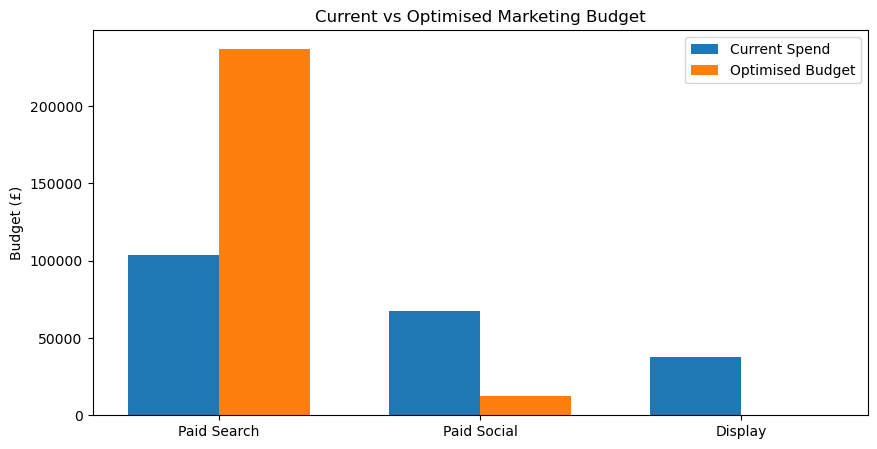

In [144]:
plt.figure(figsize=(10,5))

x = np.arange(len(budget_comparison["Channel"]))

width = 0.35

plt.bar(
    x - width/2,
    budget_comparison["Current Spend"],
    width,
    label="Current Spend"
)

plt.bar(
    x + width/2,
    budget_comparison["Optimised Budget"],
    width,
    label="Optimised Budget"
)

plt.xticks(
    x,
    budget_comparison["Channel"]
)

plt.ylabel("Budget (£)")
plt.title("Current vs Optimised Marketing Budget")

plt.legend()

plt.show()

# Export Model Outputs

The final MMM outputs are exported as CSV files for reporting and further analysis.

In [151]:
output_path = r"C:\& Satheesh\& Git\Marketing-Mix-Modelling-Budget-Optimisation\output"

channel_summary.to_csv(
    output_path + r"\channel_contribution.csv",
    index=False
)

In [153]:
roi_analysis.to_csv(
    output_path + r"\roi_analysis.csv",
    index=False
)

In [155]:
budget_optimisation.to_csv(
    output_path + r"\budget_optimisation.csv",
    index=False
)

In [157]:
import os

os.listdir(output_path)

['budget_optimisation.csv', 'channel_contribution.csv', 'roi_analysis.csv']